In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path.home() / "kkbox-churn" / "data" / "parquet"

master = pd.read_parquet(DATA_DIR / "master_dataset.parquet")
print(f"Master shape: {master.shape}")
print(f"Churn rate: {master['is_churn'].mean():.4f}")

Master shape: (970960, 107)
Churn rate: 0.0899


In [ ]:
cluster_features = [
    # Recency
    'days_since_last_transaction',
    'days_to_expiry',
    # Frequency
    'total_transactions',
    'active_days_30d',
    'active_days_all',
    # Monetary
    'total_amount_paid',
    'avg_amount_paid',
    'pay_per_day',
    # Engagement
    'auto_renew_rate',
    'listening_trend_ratio',
    'secs_30d',
    # Loyalty
    'customer_tenure_days',
    'cancel_rate'
]

# Filter to only cols that exist
cluster_features = [c for c in cluster_features if c in master.columns]
print(f"Clustering features ({len(cluster_features)}): {cluster_features}")

cluster_df = master[['msno', 'is_churn'] + cluster_features].copy()

# Fix nulls properly:
# days_since_last_listen removed from cluster features — too many nulls + 999 trick doesn't work for KMeans
# listening features: fill with 0 (no activity = zero)
fill_zero = ['active_days_30d', 'active_days_all', 'secs_30d', 'listening_trend_ratio']
for col in fill_zero:
    if col in cluster_df.columns:
        cluster_df[col] = cluster_df[col].fillna(0)

print(f"\nCluster df shape: {cluster_df.shape}")
print(f"Remaining nulls:\n{cluster_df.isnull().sum()[cluster_df.isnull().sum() > 0]}")

Clustering features (13): ['days_since_last_transaction', 'days_to_expiry', 'total_transactions', 'active_days_30d', 'active_days_all', 'total_amount_paid', 'avg_amount_paid', 'pay_per_day', 'auto_renew_rate', 'listening_trend_ratio', 'secs_30d', 'customer_tenure_days', 'cancel_rate']

Cluster df shape: (970960, 15)
Remaining nulls:
pay_per_day    1
dtype: int64


In [ ]:
from sklearn.preprocessing import RobustScaler

# Fill single null
cluster_df['pay_per_day'] = cluster_df['pay_per_day'].fillna(
    cluster_df['pay_per_day'].median()
)

# Use RobustScaler — handles outliers better than StandardScaler for KMeans
# Uses median and IQR instead of mean and std
X_cluster = cluster_df[cluster_features].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Scaled shape: {X_scaled.shape}")
print(f"Any nulls after scaling: {np.isnan(X_scaled).sum()}")
print(f"\nFeature ranges after scaling (should be roughly -3 to 3):")
for i, col in enumerate(cluster_features):
    print(f"  {col:<35} min:{X_scaled[:,i].min():.2f}  max:{X_scaled[:,i].max():.2f}")

Scaled shape: (970960, 13)
Any nulls after scaling: 0

Feature ranges after scaling (should be roughly -3 to 3):
  days_since_last_transaction         min:-0.78  max:44.72
  days_to_expiry                      min:-909.16  max:110.26
  total_transactions                  min:-1.07  max:15.13
  active_days_30d                     min:-0.58  max:0.71
  active_days_all                     min:-0.49  max:1.59
  total_amount_paid                   min:-0.93  max:6.57
  avg_amount_paid                     min:-2.81  max:37.19
  pay_per_day                         min:-2.77  max:1.43
  auto_renew_rate                     min:-1.00  max:0.00
  listening_trend_ratio               min:-0.61  max:884179.59
  secs_30d                            min:-0.36  max:18.91
  customer_tenure_days                min:-1.17  max:0.55
  cancel_rate                         min:0.00  max:1.00


In [ ]:
cluster_df2 = cluster_df[cluster_features].copy()

# Fill single null
cluster_df2['pay_per_day'] = cluster_df2['pay_per_day'].fillna(
    cluster_df2['pay_per_day'].median()
)

# Clip at 1st and 99th percentile for each feature
for col in cluster_features:
    p1  = cluster_df2[col].quantile(0.01)
    p99 = cluster_df2[col].quantile(0.99)
    cluster_df2[col] = cluster_df2[col].clip(p1, p99)

# Rescale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(cluster_df2)

print(f"Any nulls: {np.isnan(X_scaled).sum()}")
print(f"\nFeature ranges after clipping + scaling:")
for i, col in enumerate(cluster_features):
    print(f"  {col:<35} min:{X_scaled[:,i].min():.2f}  max:{X_scaled[:,i].max():.2f}")

Any nulls: 0

Feature ranges after clipping + scaling:
  days_since_last_transaction         min:-0.78  max:5.67
  days_to_expiry                      min:-2.42  max:8.47
  total_transactions                  min:-1.00  max:1.00
  active_days_30d                     min:-0.58  max:0.71
  active_days_all                     min:-0.49  max:1.52
  total_amount_paid                   min:-0.84  max:1.19
  avg_amount_paid                     min:-1.04  max:14.06
  pay_per_day                         min:-1.04  max:0.83
  auto_renew_rate                     min:-1.00  max:0.00
  listening_trend_ratio               min:-0.61  max:12.14
  secs_30d                            min:-0.36  max:5.75
  customer_tenure_days                min:-1.10  max:0.55
  cancel_rate                         min:0.00  max:0.17


K=2 | Inertia: 8361035 | Silhouette: 0.7430
K=3 | Inertia: 6441215 | Silhouette: 0.6814
K=4 | Inertia: 5301967 | Silhouette: 0.2496
K=5 | Inertia: 4666637 | Silhouette: 0.2635
K=6 | Inertia: 4176962 | Silhouette: 0.2670
K=7 | Inertia: 3829592 | Silhouette: 0.2500
K=8 | Inertia: 3520586 | Silhouette: 0.2577


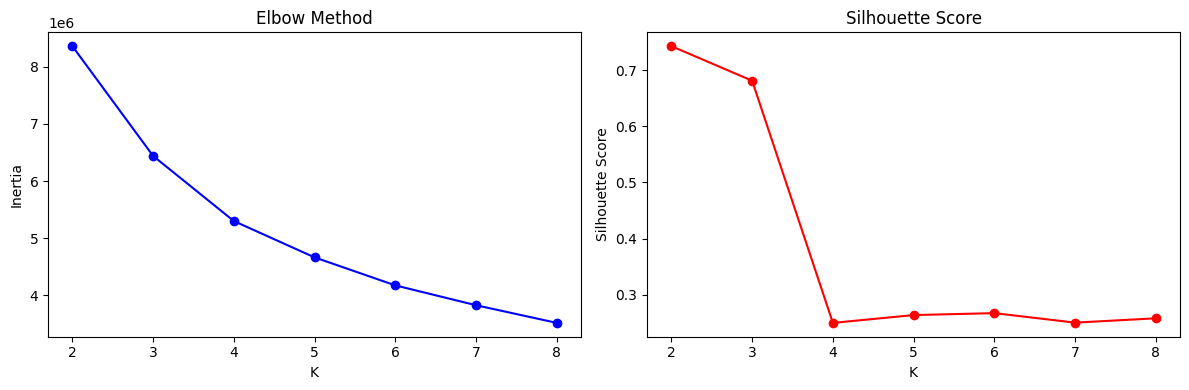

Saved elbow plot


In [5]:
# Cell 5 — Find optimal K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f"K={k} | Inertia: {km.inertia_:.0f} | Silhouette: {sil:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, 'ro-')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig(Path.home() / "kkbox-churn" / "models" / "kmeans_elbow.png", dpi=150)
plt.show()
print("Saved elbow plot")

In [6]:
# Cell 6 — Fit K=3 and inspect segments
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster_k3'] = km3.fit_predict(X_scaled)

# Churn rate and size per cluster
summary_k3 = cluster_df.groupby('cluster_k3').agg(
    size=('msno', 'count'),
    churn_rate=('is_churn', 'mean'),
).round(4)

# Add feature means per cluster
for feat in cluster_features:
    summary_k3[feat] = cluster_df.groupby('cluster_k3')[feat].mean().round(2)

print("K=3 cluster summary:")
print(summary_k3.T.to_string())

K=3 cluster summary:
cluster_k3                            0            1            2
size                         926543.000   21304.0000   23113.0000
churn_rate                        0.074       0.8082       0.0652
days_since_last_transaction      15.610      94.8500      13.3100
days_to_expiry                   16.440     146.8700      19.2200
total_transactions               17.090       3.7000      14.7800
active_days_30d                  13.860      18.3700      12.9700
active_days_all                 257.160     399.1400     160.0000
total_amount_paid              2300.520    2696.6600    1982.5700
avg_amount_paid                 132.510     923.6600     131.5300
pay_per_day                       4.300       4.3400       4.2300
auto_renew_rate                   0.890       0.1000       0.8900
listening_trend_ratio             1.000       1.8200     227.3800
secs_30d                     107447.160  156181.3300  106220.0100
customer_tenure_days            533.080     501.5000   

In [7]:
# Cell 7 — Fit K=5 and inspect segments
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_df['cluster_k5'] = km5.fit_predict(X_scaled)

summary_k5 = cluster_df.groupby('cluster_k5').agg(
    size=('msno', 'count'),
    churn_rate=('is_churn', 'mean'),
).round(4)

for feat in cluster_features:
    summary_k5[feat] = cluster_df.groupby('cluster_k5')[feat].mean().round(2)

print("K=5 cluster summary:")
print(summary_k5.T.to_string())

K=5 cluster summary:
cluster_k5                             0            1            2            3            4
size                         438200.0000   22416.0000   20561.0000  397304.0000   92479.0000
churn_rate                        0.0891       0.0651       0.8195       0.0623       0.0561
days_since_last_transaction      19.1000      13.3500      97.0100      12.2900      13.4800
days_to_expiry                    9.9600      19.1300     149.0000      22.7000      20.8900
total_transactions               11.2000      14.6800       3.5600      23.3500      18.0800
active_days_30d                   8.9800      12.8300      18.2300      15.8800      28.4100
active_days_all                  91.9400     156.6800     396.9500     392.2200     461.4500
total_amount_paid              1217.9300    1964.9600    2688.3200    3426.0300    2601.8300
avg_amount_paid                 112.8800     131.2700     942.5500     151.4600     146.3200
pay_per_day                       3.7300       4.

In [8]:
# Cell 8 — Assign business labels
label_map = {
    2: 'Lost',
    0: 'At-Risk',
    1: 'New_Reengaged',
    3: 'Champion',
    4: 'Power_Listener'
}

cluster_df['segment'] = cluster_df['cluster_k5'].map(label_map)

print("Segment distribution:")
print(cluster_df.groupby('segment').agg(
    size=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).sort_values('churn_rate', ascending=False).round(4).to_string())

# Save segment labels
segments_out = cluster_df[['msno', 'cluster_k5', 'segment']].copy()
segments_out.to_parquet(DATA_DIR / "user_segments.parquet", index=False)

# Save KMeans model and scaler
import joblib
joblib.dump(km5, Path.home() / "kkbox-churn" / "models" / "kmeans_k5.pkl")
joblib.dump(scaler, Path.home() / "kkbox-churn" / "models" / "cluster_scaler.pkl")
print("\nSaved segments, kmeans model and scaler.")

Segment distribution:
                  size  churn_rate
segment                           
Lost             20561      0.8195
At-Risk         438200      0.0891
New_Reengaged    22416      0.0651
Champion        397304      0.0623
Power_Listener   92479      0.0561

Saved segments, kmeans model and scaler.


In [9]:
# Cell 9 — Add segments to master dataset
master = pd.read_parquet(DATA_DIR / "master_dataset.parquet")
segments = pd.read_parquet(DATA_DIR / "user_segments.parquet")

master = master.merge(segments[['msno', 'segment', 'cluster_k5']], on='msno', how='left')

print(f"Master shape: {master.shape}")
print(f"Segment nulls: {master['segment'].isnull().sum()}")

master.to_parquet(DATA_DIR / "master_dataset.parquet", index=False)
print("Saved master with segments.")

Master shape: (970960, 109)
Segment nulls: 0
Saved master with segments.
